In [1]:
import os
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file, EnergyDependentMultiGaussPSF
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit, least_squares, nnls, brentq

In [2]:
name = "Mrk421"
blazar_coord = SkyCoord.from_name(name)
data_folder = "../cta_dc_data/mrk_421/"
data_folder = data_folder+"40deg/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder+ filename))
    
irf_40deg = load_irf_dict_from_file(irf_file)
print(f"Pointings 40deg: {len(hbus)}")

Pointings 40deg: 81


In [4]:
pointing_sep_avg = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )
    
    pointing_sep = pointing_coord.separation(blazar_coord).degree
    pointing_sep_avg += pointing_sep

pointing_sep_avg /= len(hbus)
print(pointing_sep_avg)

0.699999995981589


In [5]:
e_bins=np.logspace(np.log10(0.01), np.log10(10), 11)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,pointing_sep_avg**2/4, 100)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

In [6]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )

        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    
    return cts_s, cts_b, t_expo

In [7]:
bkg_subtraction_radius = pointing_sep_avg

cts_s, cts_b, t_expo = collect_data(hbus)

print(f"Exposure time 40deg = {t_expo/60/60:.1f}h")

Exposure time 40deg = 11.3h


In [8]:
cts = cts_s - cts_b
cts_err = np.sqrt(np.maximum(cts_s + cts_b, 1))

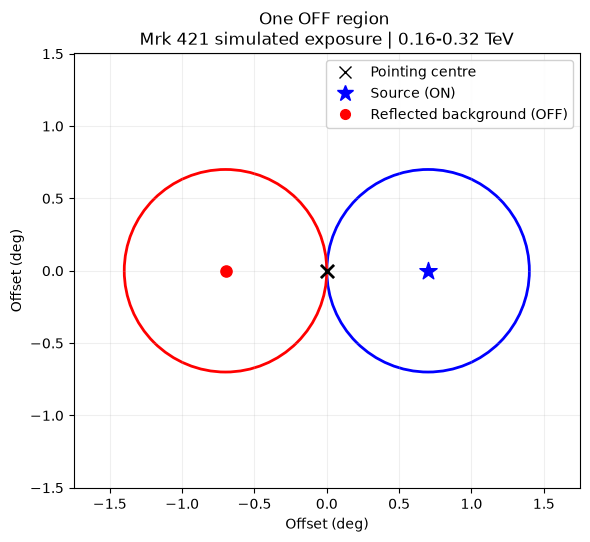

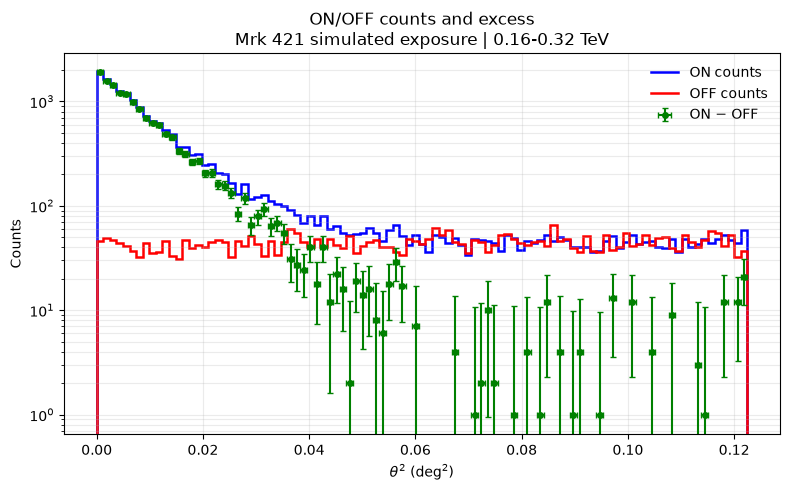

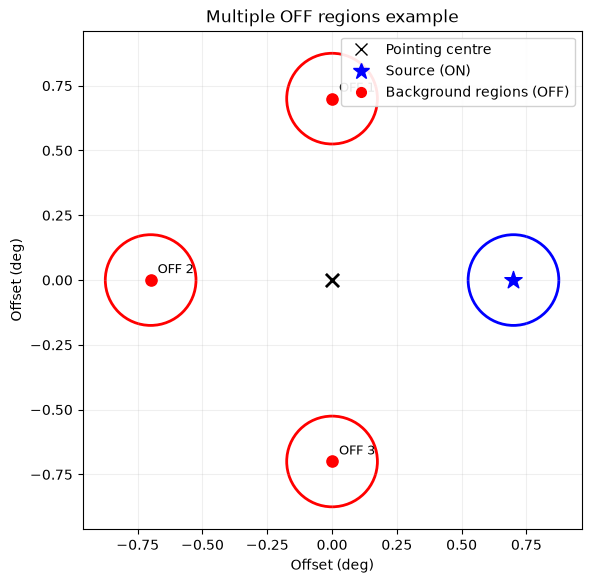

In [24]:
# Plot 1: reflected-region geometry with one OFF region
fig_geom, ax_geom = plt.subplots(figsize=(6, 6))

ax_geom.set_aspect("equal")
ax_geom.set_title(f"One OFF region \n{title_label}")
ax_geom.set_xlabel("Offset (deg)")
ax_geom.set_ylabel("Offset (deg)")

pnt = (0.0, 0.0)
src = (offset, 0.0)
bkg = (-offset, 0.0)

ax_geom.scatter(*pnt, marker="x", s=90, linewidths=2,
                color="black", zorder=5)
ax_geom.scatter(*src, marker="*", s=170,
                color="blue", zorder=5)
ax_geom.scatter(*bkg, marker="o", s=65,
                color="red", zorder=5)

ax_geom.add_patch(
    Circle(src, aperture_radius, fill=False,
           color="blue", linewidth=2)
)
ax_geom.add_patch(
    Circle(bkg, aperture_radius, fill=False,
           color="red", linewidth=2)
)

legend_handles = [
    Line2D([], [], marker="x", color="black", linestyle="None",
           markersize=9, label="Pointing centre"),
    Line2D([], [], marker="*", color="blue", linestyle="None",
           markersize=12, label="Source (ON)"),
    Line2D([], [], marker="o", color="red", linestyle="None",
           markersize=7, label="Reflected background (OFF)"),
]
ax_geom.legend(handles=legend_handles, loc="upper right",
               frameon=True, framealpha=0.9)

pad = aperture_radius * 1.5
ax_geom.set_xlim(-offset - pad, offset + pad)
ax_geom.set_ylim(-offset * 0.65 - pad, offset * 0.65 + pad)
ax_geom.grid(alpha=0.2)

fig_geom.tight_layout()


# Plot 2: counts versus theta^2
fig_counts, ax_counts = plt.subplots(figsize=(8, 5))

ax_counts.set_title(f"ON/OFF counts and excess\n{title_label}")
ax_counts.set_xlabel(r"$\theta^2$ (deg$^2$)")
ax_counts.set_ylabel("Counts")
ax_counts.set_yscale("log")

# Log axes cannot display zero or negative counts.
ax_counts.stairs(np.where(on > 0, on, np.nan), th2_edges,
                 color="blue", linewidth=1.8, label="ON counts")
ax_counts.stairs(np.where(off > 0, off, np.nan), th2_edges,
                 color="red", linewidth=1.8, label="OFF counts")

# Plot excess points without a connecting line.
positive_excess = excess > 0
ax_counts.errorbar(
    th2_centers[positive_excess],
    excess[positive_excess],
    yerr=excess_err[positive_excess],
    xerr=th2_widths[positive_excess] / 2,
    fmt="o", color="green", markersize=4, capsize=2,
    label="ON $-$ OFF"
)

ax_counts.legend(frameon=False)
ax_counts.grid(alpha=0.25, which="both")

fig_counts.tight_layout()

fig_multi, ax_multi = plt.subplots(figsize=(6, 6))

ax_multi.set_aspect("equal")
ax_multi.set_title(
    f"Multiple OFF regions example"
)
ax_multi.set_xlabel("Offset (deg)")
ax_multi.set_ylabel("Offset (deg)")

schematic_radius = min(aperture_radius, 0.25 * offset)

ax_multi.scatter(*pnt, marker="x", s=90, linewidths=2,
                 color="black", zorder=5)
ax_multi.scatter(*src, marker="*", s=170,
                 color="blue", zorder=5)
ax_multi.add_patch(
    Circle(src, schematic_radius, fill=False,
           color="blue", linewidth=2)
)

off_angles = np.deg2rad([90, 180, 270])
off_centres = [
    (offset * np.cos(angle), offset * np.sin(angle))
    for angle in off_angles
]

for i, centre in enumerate(off_centres, start=1):
    ax_multi.scatter(*centre, marker="o", s=65,
                     color="red", zorder=5)
    ax_multi.add_patch(
        Circle(centre, schematic_radius, fill=False,
               color="red", linewidth=2)
    )
    ax_multi.annotate(
        f"OFF {i}", centre, xytext=(5, 5),
        textcoords="offset points", fontsize=9
    )

multi_legend = [
    Line2D([], [], marker="x", color="black", linestyle="None",
           markersize=9, label="Pointing centre"),
    Line2D([], [], marker="*", color="blue", linestyle="None",
           markersize=12, label="Source (ON)"),
    Line2D([], [], marker="o", color="red", linestyle="None",
           markersize=7, label="Background regions (OFF)"),
]
ax_multi.legend(handles=multi_legend, loc="upper right",
                frameon=True, framealpha=0.9)

multi_pad = schematic_radius * 1.5
ax_multi.set_xlim(-offset - multi_pad, offset + multi_pad)
ax_multi.set_ylim(-offset - multi_pad, offset + multi_pad)
ax_multi.grid(alpha=0.2)

fig_multi.tight_layout()
fig_geom.savefig("reflected_region_geometry.png", dpi=300, bbox_inches="tight")
fig_counts.savefig("counts_vs_theta2.png", dpi=300, bbox_inches="tight")
fig_multi.savefig("multiple_off_regions.png", dpi=300, bbox_inches="tight")
plt.show()
